<h1 align='center' style='color:blue'> Credit Risk Modeling Project</h1>

### Import Necessary libraries 

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

### Load dtasets 

In [2]:
df_customers = pd.read_csv("dataset/customers.csv")
df_loans = pd.read_csv("dataset/loans.csv")
df_bureau = pd.read_csv("dataset/bureau_data.csv")

In [3]:
print(f" customer : {df_customers.shape} , loans : {df_loans.shape} , bureau_data : {df_bureau.shape} " )

 customer : (50000, 12) , loans : (50000, 15) , bureau_data : (50000, 8) 


In [4]:
df_customers.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [5]:
df_loans.sample(5)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
37100,L37101,C37101,Education,Secured,2391000,2001000,40020.00,360180,1600800,38,850906,451501,2023-04-08,2023-04-23,False
28098,L28099,C28099,Education,Secured,6748000,6563000,131260.00,1181340,5250400,43,2248712,1194055,2022-05-15,2022-05-23,False
27513,L27514,C27514,Auto,Secured,1612000,1165000,23300.00,209700,932000,19,838799,477714,2022-04-23,2022-05-20,False
30777,L30778,C30778,Auto,Secured,2264000,2098000,41960.00,377640,1678400,24,656149,298068,2022-08-21,2022-09-08,False
39925,L39926,C39926,Auto,Secured,923000,678000,13560.00,122040,542400,34,366850,235611,2023-07-20,2023-08-17,False


In [6]:
df_bureau.tail(5)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
49995,C49996,4,2,165,1,6,8,24
49996,C49997,4,0,161,0,0,4,91
49997,C49998,4,1,42,0,0,7,38
49998,C49999,1,2,42,9,47,4,17
49999,C50000,2,0,65,13,66,7,28


### Merge All Datasets 

In [7]:
df = pd.merge(df_customers , df_loans , on="cust_id") 
df.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [8]:
df = pd.merge(df, df_bureau , on="cust_id") 
df.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [9]:
df.shape

(50000, 33)

In [10]:
# Known the type datasets 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [11]:
df.head()


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [12]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

default is a target variable and we can see some class imbalance here. 

### Train Test Split 

We perform train test split before doing EDA to prevent data leakage. We don't want test set (which is part of the entire dataset) to influence EDA or any decisions on feature engineering. 

In [13]:
X = df.drop("default", axis="columns")
y = df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

df_train.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0


In [14]:
print(df_train.shape , df_test.shape)

(37500, 33) (12500, 33)


In [15]:
y_test.shape

(12500,)

<h1 align='center' style='color:blue'>Data Cleaning</h1>

In [16]:
df_train.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [17]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [18]:
mode_residence = df_train["residence_type"].mode()[0]
mode_residence

'Owned'

In [19]:
df_train.fillna(mode_residence , inplace=True)

In [20]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [21]:
df_test.fillna(mode_residence , inplace=True)

### Duplicate value 

In [22]:
df_train.duplicated().sum()

np.int64(0)

In [23]:
#check 
df_test.shape

(12500, 33)

In [24]:
y_test.shape

(12500,)

### Box plot for visualized outlier 

In [25]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [26]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [27]:
categprical_columns = df_train.select_dtypes(include=['object']).columns
categprical_columns

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [ ]:
n_cols = 3                  # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols   # ceiling division

plt.figure(figsize=(n_cols * 5, n_rows * 4))  # width ≈ 5 per plot, height ≈ 4 per row

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_train[col], color='lightblue')
    plt.title(col, fontsize=11)
    plt.ylabel('')          # optional: remove y-label if too crowded
    plt.grid(alpha=0.3)

plt.tight_layout()          # prevents overlap
plt.show()

In [ ]:
n_cols = 3                  # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols   # ceiling division

plt.figure(figsize=(n_cols * 5, n_rows * 4))  # width ≈ 5 per plot, height ≈ 4 per row

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(y=df_train[col], color='lightblue')
    plt.title(col, fontsize=11)
    plt.ylabel('')          # optional: remove y-label if too crowded
    plt.grid(alpha=0.3)

plt.tight_layout()          # prevents overlap
plt.show()

In [28]:
df_train.processing_fee.describe()

count     37500.00
mean      80290.68
std      113128.14
min           0.00
25%       19220.00
50%       44600.00
75%       92420.00
max     5293543.52
Name: processing_fee, dtype: float64

In [29]:
df_train[df_train.processing_fee == df_train.processing_fee.max()]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
9898,C09899,56,M,Married,Self-Employed,8948000,5,Owned,16,Ahmedabad,...,2020-07-19,2020-08-11,2,1,51,1,5,3,92,0


In [30]:
df_train[df_train.processing_fee == df_train.processing_fee.max()][["loan_amount" , "processing_fee"]]

,loan_amount,processing_fee
9898,3626000,5293543.52


In [31]:
df_train[df_train.processing_fee > df_train.loan_amount][["loan_amount" , "processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


In [32]:
df_train[(df_train.processing_fee / df_train.loan_amount) > 0.03][["loan_amount" , "processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


In [33]:
df_train_1 = df_train[(df_train.processing_fee / df_train.loan_amount) < 0.03].copy()
df_train_1[(df_train_1.processing_fee / df_train_1.loan_amount) > 0.03][["loan_amount" , "processing_fee"]]

,loan_amount,processing_fee


In [34]:
df_train_1.shape

(37488, 33)

In [35]:
df_test.shape

(12500, 33)

In [36]:
df_test = df_test[(df_test.processing_fee / df_test.loan_amount) < 0.03].copy()

In [37]:
df_test.shape

(12497, 33)

In [38]:
y_test.shape

(12500,)

In [39]:
categprical_columns

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [40]:
for columns in categprical_columns : 
    print( columns ,  "-- " , df_train_1[columns].unique())

cust_id --  ['C12747' 'C32496' 'C43676' ... 'C45237' 'C49229' 'C37785']
gender --  ['M' 'F']
marital_status --  ['Married' 'Single']
employment_status --  ['Self-Employed' 'Salaried']
residence_type --  ['Owned' 'Mortgage' 'Rented']
city --  ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --  ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
loan_id --  ['L12747' 'L32496' 'L43676' ... 'L45237' 'L49229' 'L37785']
loan_purpose --  ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --  ['Secured' 'Unsecured']
disbursal_date --  ['2020-10-31' '2022-10-22' '2023-12-04' ... '2022-02-07' '2019-10-30'
 '2022-10-04']
installment_start_dt --  ['2020-11-11' '2022-10-27' '2023-12-29' ... '2024-08-19' '2019-07-28'
 '2019-07-25']


In [41]:
df_train_1["loan_purpose"] = df_train_1["loan_purpose"].replace('Personaal' , 'Personal')
df_test["loan_purpose"] = df_test["loan_purpose"].replace('Personaal' , 'Personal')

df_train_1.loan_purpose.unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

<h1 align='center' style='color:blue'>Exploratory Data analysis</h1>

In [ ]:
sns.histplot(df_train_1.age , fill=True)

In [ ]:
sns.kdeplot(df_train_1.age , fill=True)
plt.show()

In [ ]:
sns.kdeplot(
    df_train_1[df_train_1["default"] == 0]["age"],
    fill=True,
    label="default = 0"
)
sns.kdeplot(
    df_train_1[df_train_1["default"] == 1]["age"],
    fill=True,
    label="default = 1"
)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(numeric_cols):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train_1[col][df_train_1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train_1[col][df_train_1['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

In [42]:
y_test.shape

(12500,)

<h2 align="center" , color="blue" > Feature engineering </h2>

In [43]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [44]:
### claculate loan to income 
df_train_1["loan_to_income"] = ( df_train_1["loan_amount"] / df_train_1["income"])
df_train_1[["loan_amount", "income" ,  "loan_to_income"]].head(5)

,loan_amount,income,loan_to_income
12746,23442000,11327000,2.07
32495,1149000,715000,1.61
43675,11296000,3195000,3.54
9040,1695000,1500000,1.13
13077,905000,1817000,0.50


In [45]:
df_test["loan_to_income"] = ( df_test["loan_amount"] / df_test["income"])

In [ ]:
sns.kdeplot(
    df_train_1[df_train_1["default"] == 0]["loan_to_income"],
    fill=True,
    label="default = 0"
)
sns.kdeplot(
    df_train_1[df_train_1["default"] == 1]["loan_to_income"],
    fill=True,
    label="default = 1"
)
plt.legend()
plt.show()

In [46]:
y_test.shape

(12500,)

In [47]:
# calculate deliquent ratio 
df_train_1["deliquent_ratio"] = ( df_train_1["delinquent_months"]*100 / df_train_1["total_loan_months"])
df_train_1[["delinquent_months" , "total_loan_months" , "deliquent_ratio" ]].head(5)

,delinquent_months,total_loan_months,deliquent_ratio
12746,20,152,13.16
32495,10,160,6.25
43675,12,54,22.22
9040,0,76,0.00
13077,0,60,0.00


In [48]:
df_test["deliquent_ratio"] = ( df_test["delinquent_months"]*100 / df_test["total_loan_months"])

In [ ]:
sns.kdeplot(
    df_train_1[df_train_1["default"] == 0]["deliquent_ratio"],
    fill=True,
    label="default = 0"
)
sns.kdeplot(
    df_train_1[df_train_1["default"] == 1]["deliquent_ratio"],
    fill=True,
    label="default = 1"
)
plt.legend()
plt.show()

In [49]:
# calculate the avd dpd_per_deliquence 
df_train_1["avg_dpd_per_deliquence"] = np.where(
     df_train_1["delinquent_months"] != 0,
    ( df_train_1["total_dpd"]*100 / df_train_1["delinquent_months"]),
    0
)

df_train_1["avg_dpd_per_deliquence"].isnull().sum()

np.int64(0)

In [50]:
df_test["avg_dpd_per_deliquence"] = np.where(
     df_test["delinquent_months"] != 0,
    ( df_test["total_dpd"]*100 / df_test["delinquent_months"]),
    0
)

In [ ]:
sns.kdeplot(
    df_train_1[df_train_1["default"] == 0]["avg_dpd_per_deliquence"],
    fill=True,
    label="default = 0"
)
sns.kdeplot(
    df_train_1[df_train_1["default"] == 1]["avg_dpd_per_deliquence"],
    fill=True,
    label="default = 1"
)
plt.legend()
plt.show()

In [51]:
y_test.shape

(12500,)

<h2 align="center" , color="blue" > Feature selection </h2>

In [52]:
df_train_1.columns 

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'deliquent_ratio', 'avg_dpd_per_deliquence'],
      dtype='object')

In [53]:
df_train_2 = df_train_1.drop(["cust_id" , "loan_id"] , axis = "columns")
df_test= df_test.drop(["cust_id" , "loan_id"] , axis = "columns")
df_train_2.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquent_ratio', 'avg_dpd_per_deliquence'],
      dtype='object')

In [54]:
df_train_3 = df_train_2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquent_ratio', 'avg_dpd_per_deliquence'],
      dtype='object')

### Calculate Varaince Inflation factor 

### Scaling     

In [55]:
numeric_cols_3 = df_train_3.select_dtypes(include=['int64', 'float64']).columns
numeric_cols_3

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquent_ratio', 'avg_dpd_per_deliquence'],
      dtype='object')

In [56]:
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquent_ratio', 'avg_dpd_per_deliquence'],
      dtype='object')

In [57]:
from sklearn.preprocessing import MinMaxScaler

X_train = df_train_3.drop('default' , axis="columns")
y_train = df_train_3['default']

cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
df_test[cols_to_scale] = scaler.fit_transform(df_test[cols_to_scale])

X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquence
count,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.40,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.62,0.68,0.51,0.13,0.57
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [58]:
X_test = df_test.drop('default', axis='columns')
y_test = df_test['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquence
count,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00
mean,-0.34,0.08,-0.02,-0.19,-0.00,-0.00,-0.00,-0.00,-0.11,-0.01,-0.00,-0.17,0.25,-0.06,0.00,-0.00,0.00,0.00
std,0.00,0.06,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.20,0.03,0.00,0.05,0.00,0.00
min,-0.35,0.00,-0.03,-0.19,-0.00,-0.00,-0.00,-0.00,-0.11,-0.01,-0.00,-0.33,0.00,-0.12,0.00,-0.07,0.00,0.00
25%,-0.34,0.00,-0.03,-0.19,-0.00,-0.00,-0.00,-0.00,-0.11,-0.01,-0.00,-0.33,0.00,-0.08,0.00,-0.04,0.00,0.00
50%,-0.34,0.08,-0.02,-0.19,-0.00,-0.00,-0.00,-0.00,-0.11,-0.01,-0.00,-0.22,0.25,-0.06,0.00,-0.02,0.00,0.00
75%,-0.34,0.12,-0.01,-0.19,-0.00,-0.00,-0.00,-0.00,-0.10,-0.01,-0.00,-0.11,0.50,-0.05,0.01,0.05,0.00,0.00
max,-0.33,0.20,-0.00,-0.19,-0.00,-0.00,-0.00,-0.00,-0.09,-0.01,-0.00,0.00,0.50,0.00,0.01,0.16,0.01,0.00


In [59]:
y_test.shape

(12497,)

In [60]:
# calculate the vif 
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calVif(data) : 
    vif_df = pd.DataFrame()
    vif_df["columns"] = data.columns
    vif_df["vif"] = [variance_inflation_factor(data.values , i ) for i in range (data.shape[1])] 
    return vif_df 

In [61]:
calVif(X_train[cols_to_scale])

C:\Users\123\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,columns,vif
0,age,5.70
1,number_of_dependants,2.73
2,years_at_current_address,3.42
3,zipcode,3.80
4,sanction_amount,101.09
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.18
9,principal_outstanding,16.33


In [62]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']

X_train_1 = X_train.drop(features_to_drop_vif , axis="columns")
numeric_col = X_train_1.select_dtypes(include=['int64', 'float64']).columns
numeric_col


Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'deliquent_ratio',
       'avg_dpd_per_deliquence'],
      dtype='object')

In [63]:
calVif(X_train_1[numeric_col])

,columns,vif
0,age,5.43
1,number_of_dependants,2.73
2,years_at_current_address,3.40
3,zipcode,3.78
4,loan_tenure_months,6.02
5,bank_balance_at_application,1.80
6,number_of_open_accounts,4.35
7,number_of_closed_accounts,2.37
8,enquiry_count,6.38
9,credit_utilization_ratio,2.92


In [64]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'deliquent_ratio',
       'avg_dpd_per_deliquence'],
      dtype='object')

In [65]:
vif_df = calVif(X_train_1[numeric_columns])
vif_df

,columns,vif
0,age,5.43
1,number_of_dependants,2.73
2,years_at_current_address,3.40
3,zipcode,3.78
4,loan_tenure_months,6.02
5,bank_balance_at_application,1.80
6,number_of_open_accounts,4.35
7,number_of_closed_accounts,2.37
8,enquiry_count,6.38
9,credit_utilization_ratio,2.92


In [66]:
selected_numeric_features_vif = vif_df["columns"].tolist()
selected_numeric_features_vif

['age',
 'number_of_dependants',
 'years_at_current_address',
 'zipcode',
 'loan_tenure_months',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'deliquent_ratio',
 'avg_dpd_per_deliquence']

### Correlation_matrix

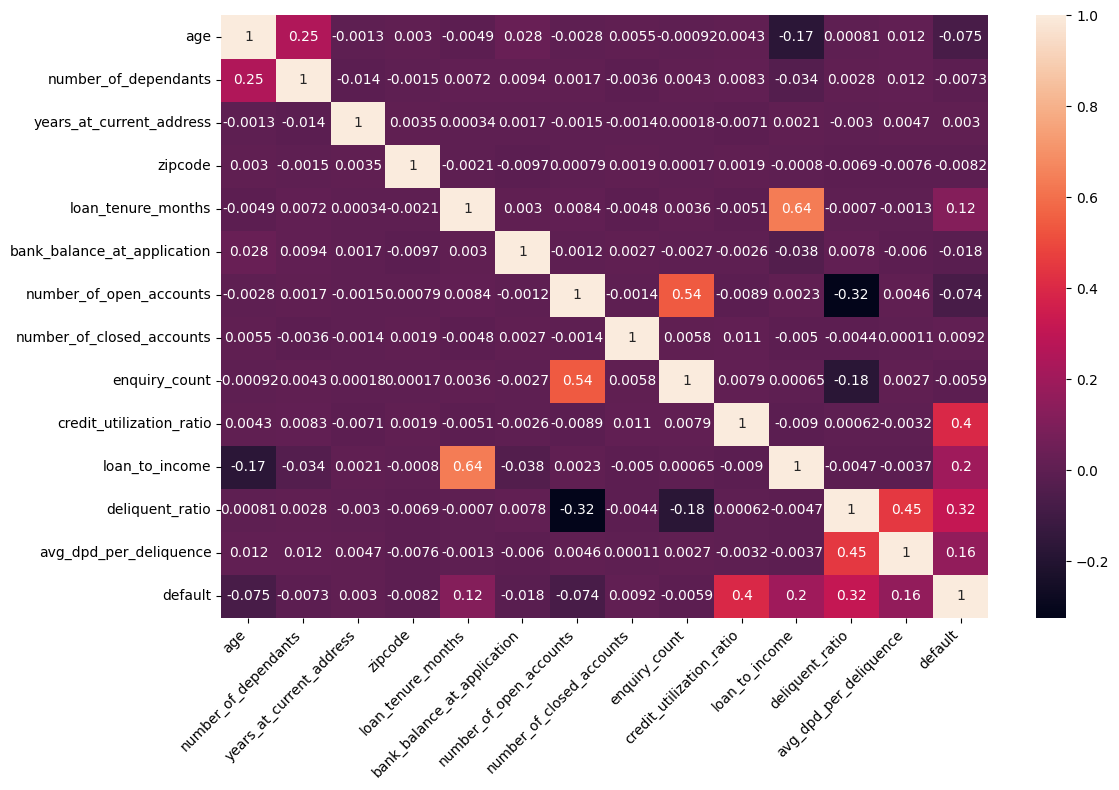

In [67]:
plt.figure(figsize=(12, 8))
cm = df_train_3[numeric_columns.append(pd.Index(["default"]))].corr()
sns.heatmap(cm , annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [68]:
y_test.shape

(12497,)

<h2 align="center"> Weight of evidence and IV </h2>

In [69]:
def calculate_woe_iv(df , features , target ) : 

    # groupby the features and target . 
    grouped = df.groupby(features)[target].agg(["count" , "sum"])

    # rename the grouped columns 
    grouped =  grouped.rename(columns={"count" : "total" , "sum" : "good"})

    # find the bad grouped
    grouped["bad"] =  grouped["total"] - grouped["good"] 
    
    # sum total good and bad 
    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum() 

    # good & bad percentage 
    grouped["good_pct"] = grouped["good"] / total_good
    grouped["bad_pct"] = grouped["bad"] / total_bad 

    # calculate weight_of_evidence 
    grouped["woe"] = np.log(grouped["good_pct"] / grouped["bad_pct"])

    # calcualte IV 
    grouped["IV"] = (grouped["good_pct"] / grouped["bad_pct"] * grouped["woe"] )

    # replace infinty with 0 
    grouped["woe"] = grouped["woe"].replace([np.inf , -np.inf],0)
    grouped["IV"] = grouped["IV"].replace([np.inf , -np.inf],0)

    # calculate total IV 
    total_Iv = grouped["IV"].sum()

    # return the grouped and total_iv 
    return grouped , total_Iv

    
    

grouped , total_Iv = calculate_woe_iv(pd.concat([X_train_1 , y_train] , axis=1) , "loan_purpose" , "default")
grouped 

,total,good,bad,good_pct,bad_pct,woe,IV
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,-0.35
Education,5620,559,5061,0.17,0.15,0.16,0.19
Home,11304,1734,9570,0.54,0.28,0.66,1.26
Personal,13117,603,12514,0.19,0.37,-0.67,-0.34


In [70]:
X_train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  float64
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  float64
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  float64
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  float64
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  loan_tenure_months           37488 non-null  float64
 13  bank_balance_at_a

In [71]:
iv_values = {}
for feature in X_train_1.columns : 
    if X_train_1[feature].dtype == 'object': 
        _ , iv = calculate_woe_iv(pd.concat([X_train_1 , y_train] , axis=1) , feature , "default") 
    else : 
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _ , iv = calculate_woe_iv(pd.concat([X_binned, y_train] , axis=1) , feature , "default") 
        
    iv_values[feature] = iv 

iv_values 

{'age': np.float64(-0.09627342527017119),
 'gender': np.float64(0.009590506974322208),
 'marital_status': np.float64(0.008060669787037147),
 'employment_status': np.float64(0.04275084257593141),
 'number_of_dependants': np.float64(0.04541126503497875),
 'residence_type': np.float64(1.320393209014958),
 'years_at_current_address': np.float64(-0.03100200955261411),
 'city': np.float64(0.010496325770462802),
 'state': np.float64(0.00888336612592043),
 'zipcode': np.float64(-0.02299163192030748),
 'loan_purpose': np.float64(0.7588582096067951),
 'loan_type': np.float64(-0.02592875781233417),
 'loan_tenure_months': np.float64(2.501934290323637),
 'bank_balance_at_application': np.float64(7.966665099947104),
 'number_of_open_accounts': np.float64(0.21301184745661453),
 'number_of_closed_accounts': np.float64(0.0022915111973363864),
 'enquiry_count': np.float64(0.4239877780257502),
 'credit_utilization_ratio': np.float64(22.794173728533654),
 'loan_to_income': np.float64(23.83116778340716),
 

In [72]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x)) 

iv_df = pd.DataFrame(list(iv_values.items()) , columns=["features" , "IV"])
iv_df = iv_df.sort_values(by="IV" , ascending=False)
iv_df

,features,IV
19,deliquent_ratio,127.091
18,loan_to_income,23.831
17,credit_utilization_ratio,22.794
13,bank_balance_at_application,7.967
20,avg_dpd_per_deliquence,3.548
12,loan_tenure_months,2.502
5,residence_type,1.320
10,loan_purpose,0.759
16,enquiry_count,0.424
14,number_of_open_accounts,0.213


In [73]:
# select features that has IV > 0.02 
selected_features = [ feature for feature , iv in iv_values.items() if iv > 0.02]
selected_features 

['employment_status',
 'number_of_dependants',
 'residence_type',
 'loan_purpose',
 'loan_tenure_months',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'deliquent_ratio',
 'avg_dpd_per_deliquence']

In [74]:
X_train_1[selected_features ].head()

,employment_status,number_of_dependants,residence_type,loan_purpose,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquence
12746,Self-Employed,0.600,Owned,Home,0.415,0.613,1.000,0.375,0.364,0.415,0.132,0.590
32495,Salaried,0.000,Owned,Education,0.830,0.025,0.667,0.500,0.051,0.307,0.062,0.620
43675,Salaried,0.000,Mortgage,Home,0.491,0.174,0.000,0.375,0.000,0.759,0.222,0.558
9040,Salaried,0.400,Mortgage,Education,0.642,0.078,0.667,0.875,0.879,0.195,0.000,0.000
13077,Self-Employed,0.800,Owned,Personal,0.170,0.072,0.000,0.000,0.717,0.047,0.000,0.000


In [75]:
 df_test[selected_features ].shape

(12497, 12)

In [76]:
y_test.shape

(12497,)


### Feature Encoding 

In [77]:
X_train_reduced = X_train_1[selected_features ]
X_test_reduced = df_test[selected_features ]

In [78]:
X_train_encoded = pd.get_dummies(X_train_reduced , drop_first=True)
X_train_encoded.sample(4)

,number_of_dependants,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquence,employment_status_Self-Employed,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal
10998,0.600,0.981,0.433,1.000,0.375,0.384,0.294,0.000,0.000,True,False,False,True,False,False
37918,0.000,0.340,0.040,0.333,0.375,0.152,0.621,0.000,0.000,True,True,False,False,True,False
1860,0.800,0.396,0.222,0.000,0.625,0.202,0.162,0.020,1.000,True,True,False,False,False,False
33083,0.000,0.358,0.168,0.333,0.250,0.152,0.179,0.093,0.514,False,True,False,False,False,False


In [79]:
X_test_encoded = pd.get_dummies(X_test_reduced , drop_first=True)
X_test_encoded.sample(4)

,number_of_dependants,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquence,employment_status_Self-Employed,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal
13481,0.600,0.000,0.092,0.000,0.500,0.707,0.121,0.429,0.533,True,True,False,False,False,True
21275,0.600,0.415,0.040,0.000,0.375,0.758,0.182,0.057,0.767,True,False,False,False,False,False
35640,0.400,0.245,0.212,0.667,0.250,0.475,0.241,0.206,0.771,True,False,False,False,False,False
38301,0.000,0.774,0.076,1.000,1.000,0.212,0.651,0.081,0.673,True,True,False,False,True,False


In [80]:
y_test.shape

(12497,)

<h2 align="center"> Model Training</h2>

### Logistic regression 

In [81]:
X_test_encoded.shape

(12497, 15)

In [82]:
y_test.shape

(12497,)

### Atempt one 
logistic regression , random_forest_classifier and xgboost 
without handling imbalnce class 

In [83]:
from sklearn.metrics import classification_report
model = LogisticRegression()
model.fit(X_train_encoded , y_train ) 

y_pred = model.predict(X_test_encoded)

report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.87      0.73      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.92      0.86      0.89     12497
weighted avg       0.97      0.97      0.97     12497



In [84]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train_encoded , y_train ) 

y_pred = model.predict(X_test_encoded)

report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.88      0.69      0.77      1074

    accuracy                           0.97     12497
   macro avg       0.93      0.84      0.88     12497
weighted avg       0.96      0.97      0.96     12497



In [98]:
from xgboost import XGBClassifier
model_xg = XGBClassifier()
model_xg.fit(X_train_encoded , y_train)

y_pred = model_xg.predict(X_test_encoded)

report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.84      0.76      0.80      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.87      0.89     12497
weighted avg       0.97      0.97      0.97     12497



#### RandomizedSearch CV for Attempt 1: Logistic Regression

In [101]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'saga', 'C': np.float64(206.913808111479)}
Best Score: 0.7676726554525525
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.85      0.75      0.80      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.87      0.89     12497
weighted avg       0.97      0.97      0.97     12497

